In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("marketing_campaign_data.csv")
dictionary = pd.read_csv("marketing_data_dictionary.csv")

print(df.shape)
df.head()

(56000, 28)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,2,45,6,0,16,3,2,5,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,0,19,1,19,0,1,1,0,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,0,339,0,115,138,3,2,1,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,0,130,7,1,75,1,4,0,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,3,55,242,0,0,1,3,2,3,6,0,0,0,0,0,0,0,Canada


In [5]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary")
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  object 
 3   Marital_Status       56000 non-null  object 
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  object 
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null 

,count,mean,std,min,25%,50%,75%,max
ID,56000.0,8.389352e+06,4.844638e+06,36.0,4187371.750,8383784.00,12585764.50,16777158.0
Year_Birth,56000.0,1.971667e+03,1.221107e+01,1936.0,1963.000,1973.00,1981.00,1996.0
Income,56000.0,5.725219e+04,3.430725e+04,1730.0,28252.025,58838.55,86930.65,258027.5
Kidhome,56000.0,5.399107e-01,5.213491e-01,0.0,0.000,1.00,1.00,2.0
Teenhome,56000.0,3.621429e-01,5.105670e-01,0.0,0.000,0.00,1.00,2.0
Recency,56000.0,6.322111e+01,3.115707e+01,0.0,35.000,71.00,93.00,99.0
MntWines,56000.0,2.469815e+02,3.585695e+02,0.0,0.000,64.00,353.00,1493.0
MntFruits,56000.0,1.615266e+01,3.393146e+01,0.0,0.000,0.00,15.00,199.0
MntMeatProducts,56000.0,2.682940e+02,3.421657e+02,0.0,42.000,107.00,363.00,1341.0
MntFishProducts,56000.0,5.109773e+01,7.322686e+01,0.0,3.000,13.00,71.00,259.0


Data Cleaning

In [6]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

# Handle missing income
df["Income"].fillna(df["Income"].median(), inplace=True)

print(df.isnull().sum())

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Country                0
dtype: int64


Feature Engineering

In [7]:
# Age
df["Age"] = 2025 - df["Year_Birth"]

# Customer Tenure
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure"] = (
    reference_date - df["Dt_Customer"]
).dt.days

# Children
df["Children"] = df["Kidhome"] + df["Teenhome"]

# Total Spend
spend_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spend"] = df[spend_cols].sum(axis=1)

# Total Purchases
purchase_cols = [
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

# Campaign Accepted
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

df["Campaign_Count"] = df[campaign_cols].sum(axis=1)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Age,Customer_Tenure,Children,Total_Spend,Total_Purchases,Campaign_Count
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,2,45,6,0,16,3,2,5,3,4,0,0,0,0,0,0,0,Spain,40,589,1,69,13,0
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,0,19,1,19,0,1,1,0,2,3,0,0,0,0,0,0,0,Spain,50,445,2,39,4,0
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,0,339,0,115,138,3,2,1,6,3,0,0,0,0,0,0,0,Australia,47,169,0,1512,12,0
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,0,130,7,1,75,1,4,0,11,4,0,0,0,0,0,0,0,Spain,49,11,1,478,16,0
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,3,55,242,0,0,1,3,2,3,6,0,0,0,0,0,0,0,Canada,44,40,2,330,9,0


Rule-Based Segmentation

In [8]:
# Income Band
df["Income_Band"] = pd.cut(
    df["Income"],
    bins=[0,30000,60000,90000,150000],
    labels=["Low","Medium","High","Very High"]
)

# Age Group
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18,30,40,50,60,100],
    labels=["18-30","31-40","41-50","51-60","60+"]
)

# High Spender
limit = df["Total_Spend"].quantile(0.90)

df["High_Spender"] = np.where(
    df["Total_Spend"]>=limit,
    "Yes",
    "No"
)

# High Web Engagement
df["High_Web_Engagement"] = np.where(
    df["NumWebVisitsMonth"]>5,
    "Yes",
    "No"
)

# Campaign Responder
df["Campaign_Responder"] = np.where(
    df["Response"]==1,
    "Yes",
    "No"
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Age,Customer_Tenure,Children,Total_Spend,Total_Purchases,Campaign_Count,Income_Band,Age_Group,High_Spender,High_Web_Engagement,Campaign_Responder
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,2,45,6,0,16,3,2,5,3,4,0,0,0,0,0,0,0,Spain,40,589,1,69,13,0,Medium,31-40,No,No,No
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,0,19,1,19,0,1,1,0,2,3,0,0,0,0,0,0,0,Spain,50,445,2,39,4,0,Low,41-50,No,No,No
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,0,339,0,115,138,3,2,1,6,3,0,0,0,0,0,0,0,Australia,47,169,0,1512,12,0,Very High,41-50,No,No,No
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,0,130,7,1,75,1,4,0,11,4,0,0,0,0,0,0,0,Spain,49,11,1,478,16,0,High,41-50,No,No,No
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,3,55,242,0,0,1,3,2,3,6,0,0,0,0,0,0,0,Canada,44,40,2,330,9,0,Medium,41-50,No,Yes,No


Save Clean Dataset

In [9]:
df.to_csv("marketing_campaign_cleaned.csv",index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


EDA (Univariate)

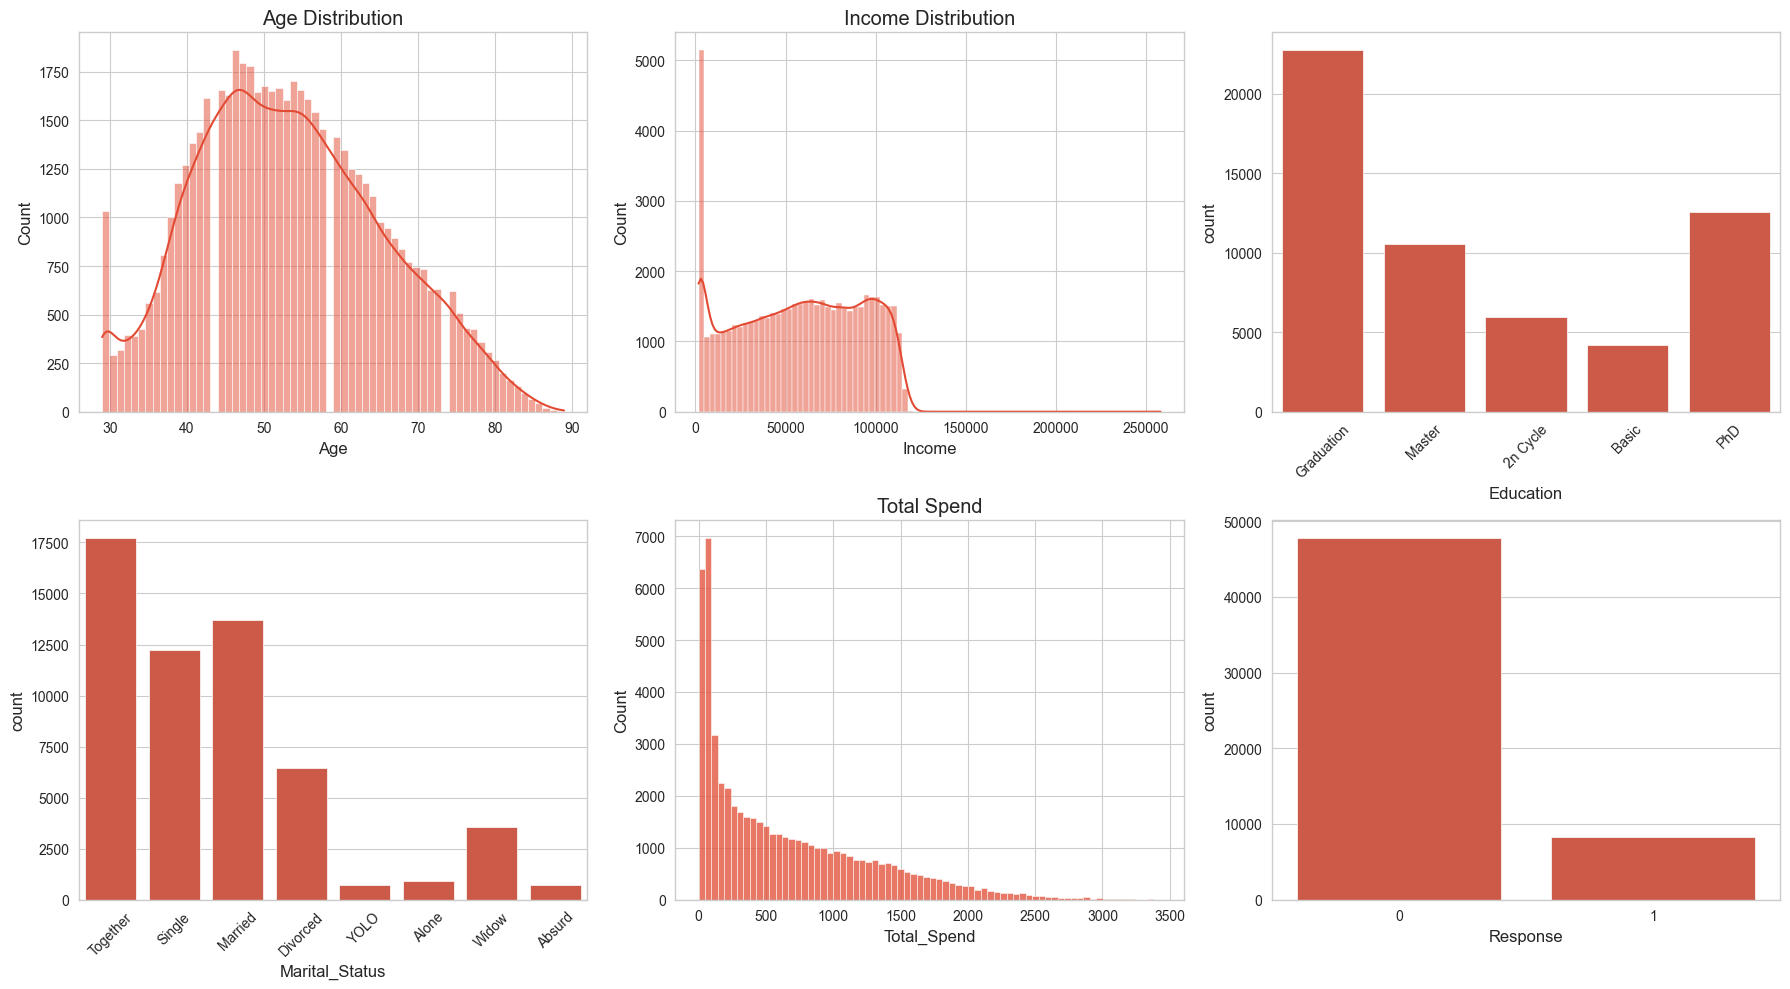

In [10]:
fig,ax=plt.subplots(2,3,figsize=(18,10))

sns.histplot(df["Age"],ax=ax[0,0],kde=True)
ax[0,0].set_title("Age Distribution")

sns.histplot(df["Income"],ax=ax[0,1],kde=True)
ax[0,1].set_title("Income Distribution")

sns.countplot(data=df,x="Education",ax=ax[0,2])
ax[0,2].tick_params(axis='x',rotation=45)

sns.countplot(data=df,x="Marital_Status",ax=ax[1,0])
ax[1,0].tick_params(axis='x',rotation=45)

sns.histplot(df["Total_Spend"],ax=ax[1,1])
ax[1,1].set_title("Total Spend")

sns.countplot(data=df,x="Response",ax=ax[1,2])

plt.tight_layout()
plt.show()

Bivariate Analysis

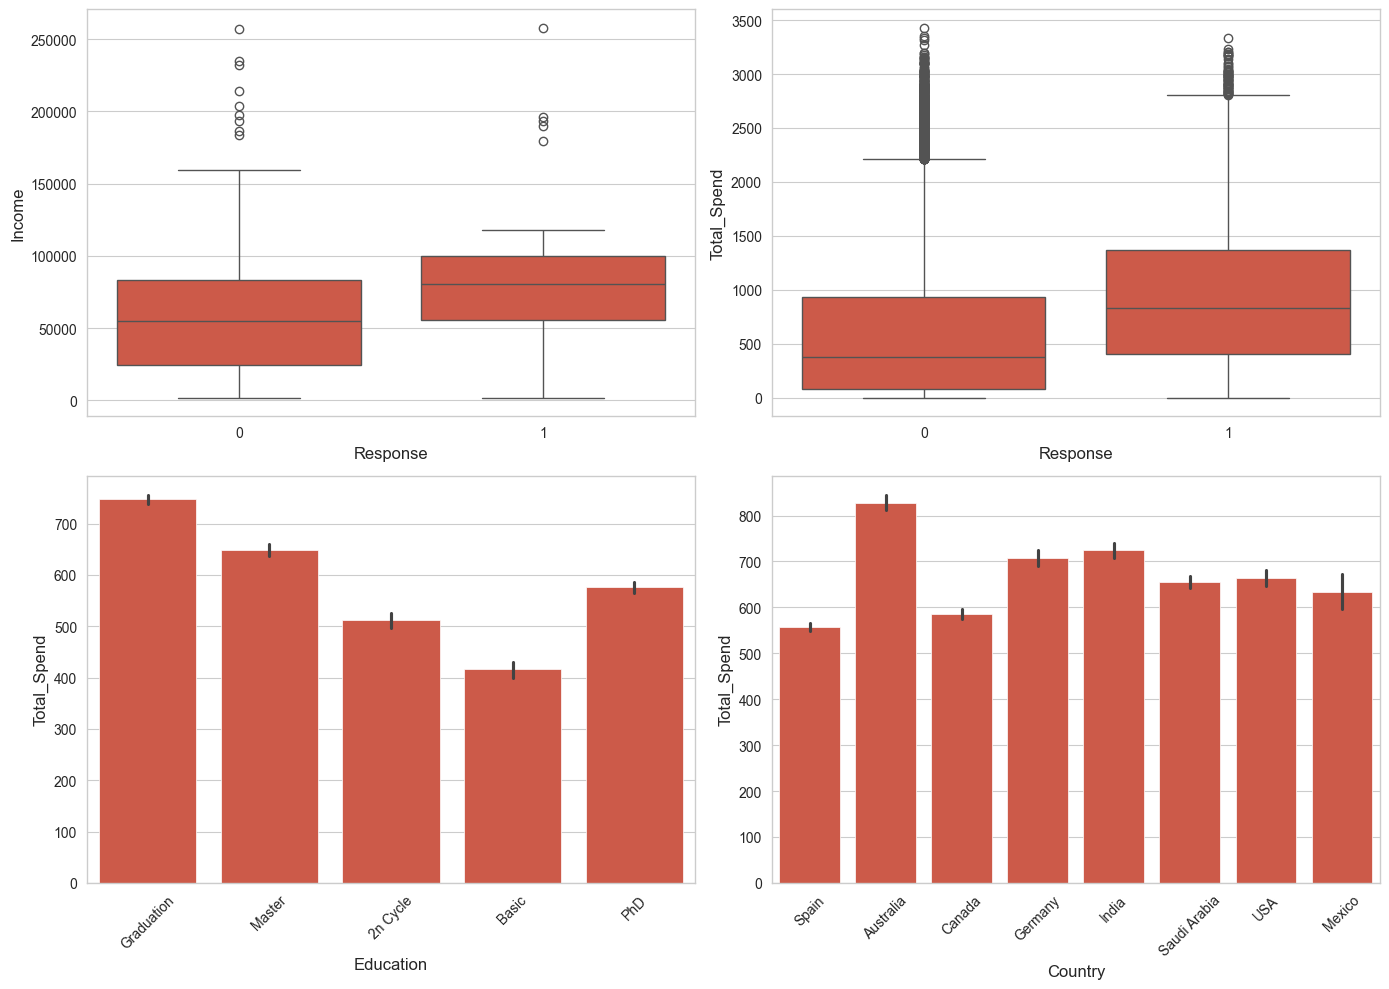

In [11]:
fig,ax=plt.subplots(2,2,figsize=(14,10))

sns.boxplot(data=df,x="Response",y="Income",ax=ax[0,0])

sns.boxplot(data=df,x="Response",y="Total_Spend",ax=ax[0,1])

sns.barplot(data=df,x="Education",y="Total_Spend",ax=ax[1,0])
ax[1,0].tick_params(axis='x',rotation=45)

sns.barplot(data=df,x="Country",y="Total_Spend",ax=ax[1,1])
ax[1,1].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

Correlation Heatmap

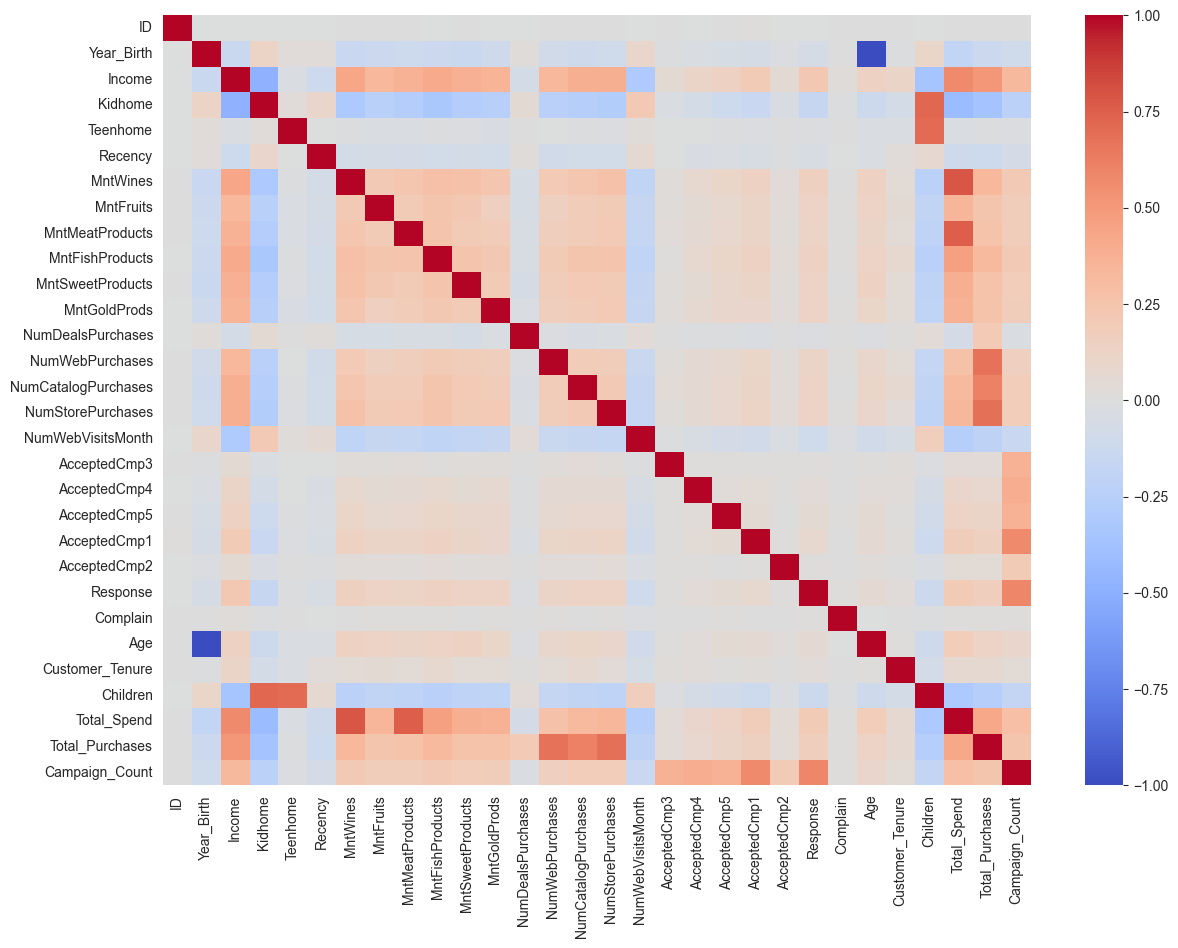

In [12]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.show()

In [13]:
print("="*50)
print("MARKETING CAMPAIGN KPI SUMMARY")
print("="*50)

print(f"Total Customers           : {df.shape[0]}")
print(f"Average Age               : {df['Age'].mean():.2f}")
print(f"Average Income            : ₹{df['Income'].mean():,.2f}")
print(f"Average Total Spend       : ₹{df['Total_Spend'].mean():,.2f}")
print(f"Average Purchases         : {df['Total_Purchases'].mean():.2f}")
print(f"Campaign Response Rate    : {df['Response'].mean()*100:.2f}%")
print(f"Average Web Visits        : {df['NumWebVisitsMonth'].mean():.2f}")
print(f"Complaint Rate            : {df['Complain'].mean()*100:.2f}%")

MARKETING CAMPAIGN KPI SUMMARY
Total Customers           : 56000
Average Age               : 53.33
Average Income            : ₹57,252.19
Average Total Spend       : ₹640.33
Average Purchases         : 13.24
Campaign Response Rate    : 14.76%
Average Web Visits        : 5.17
Complaint Rate            : 0.76%


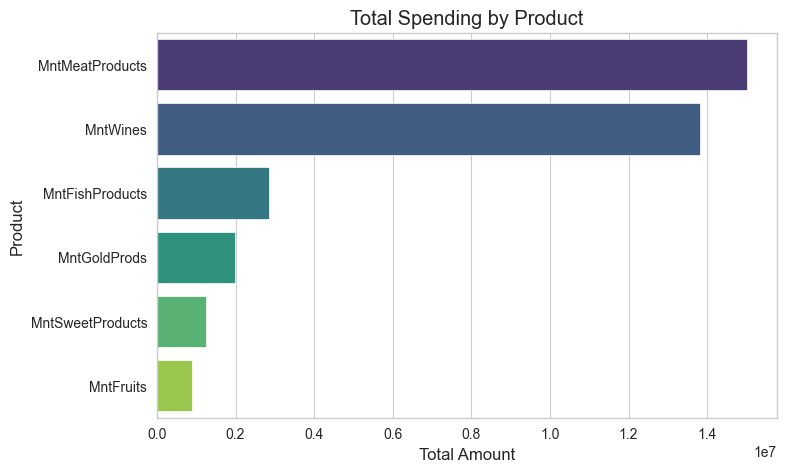

MntMeatProducts     15024465
MntWines            13830963
MntFishProducts      2861473
MntGoldProds         1981595
MntSweetProducts     1255691
MntFruits             904549
dtype: int64


In [14]:
product_spending = df[
    [
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds"
    ]
].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x=product_spending.values,
    y=product_spending.index,
    palette="viridis"
)

plt.title("Total Spending by Product")
plt.xlabel("Total Amount")
plt.ylabel("Product")

plt.show()

print(product_spending)

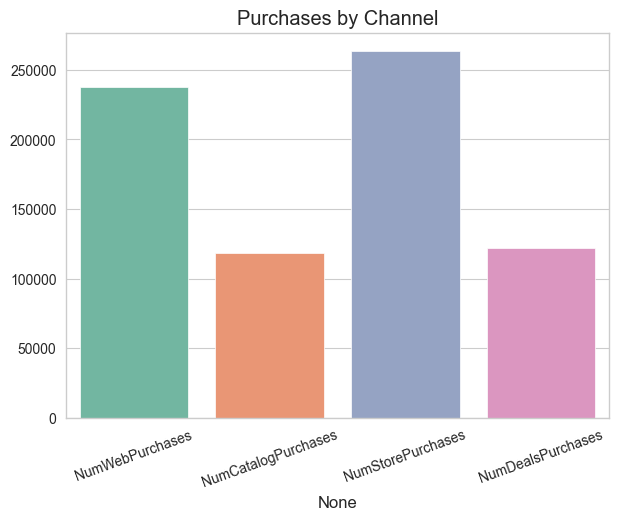

NumWebPurchases        237938
NumCatalogPurchases    118202
NumStorePurchases      263559
NumDealsPurchases      121630
dtype: int64


In [15]:
channels = df[
[
"NumWebPurchases",
"NumCatalogPurchases",
"NumStorePurchases",
"NumDealsPurchases"
]
].sum()

plt.figure(figsize=(7,5))

sns.barplot(
    x=channels.index,
    y=channels.values,
    palette="Set2"
)

plt.xticks(rotation=20)

plt.title("Purchases by Channel")

plt.show()

print(channels)

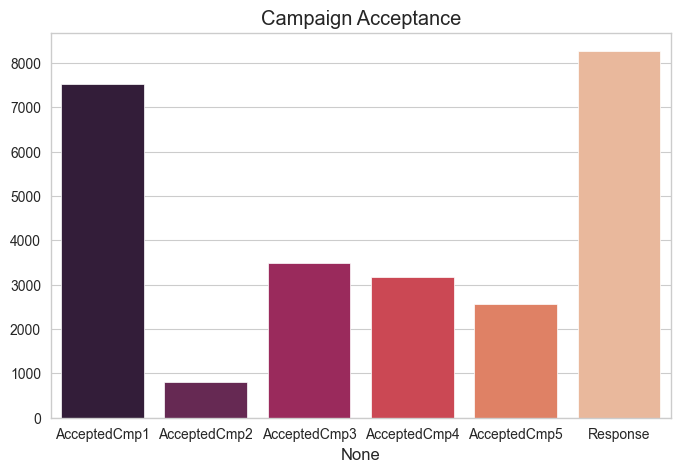

AcceptedCmp1    7529
AcceptedCmp2     807
AcceptedCmp3    3494
AcceptedCmp4    3182
AcceptedCmp5    2557
Response        8265
dtype: int64


In [16]:
campaigns = df[
[
"AcceptedCmp1",
"AcceptedCmp2",
"AcceptedCmp3",
"AcceptedCmp4",
"AcceptedCmp5",
"Response"
]
].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=campaigns.index,
    y=campaigns.values,
    palette="rocket"
)

plt.title("Campaign Acceptance")

plt.show()

print(campaigns)

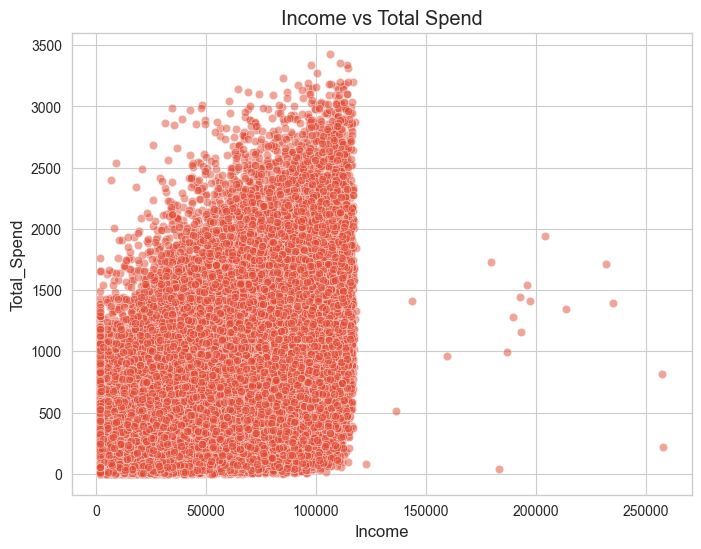

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spend",
    alpha=0.5
)

plt.title("Income vs Total Spend")

plt.show()

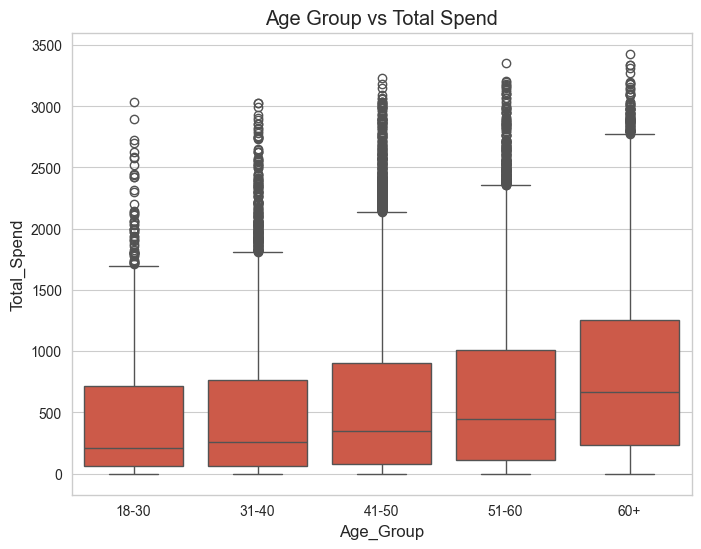

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Age_Group",
    y="Total_Spend"
)

plt.title("Age Group vs Total Spend")

plt.show()

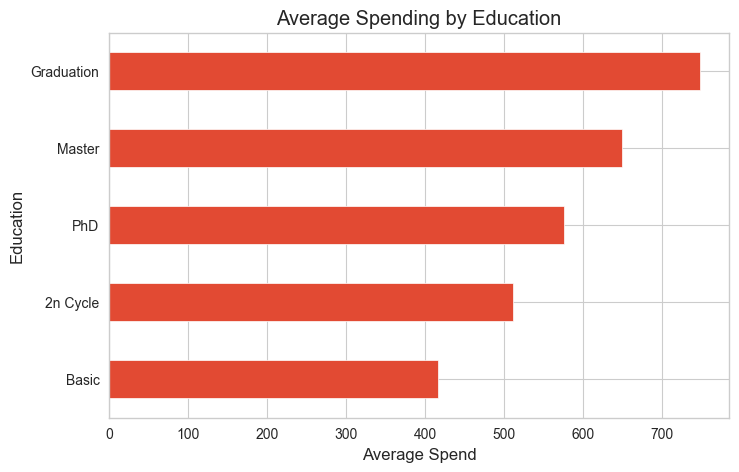

Education
Basic         416.460306
2n Cycle      511.298190
PhD           575.672125
Master        648.498670
Graduation    747.349369
Name: Total_Spend, dtype: float64


In [19]:
education = df.groupby("Education")["Total_Spend"].mean().sort_values()

plt.figure(figsize=(8,5))

education.plot(kind="barh")

plt.title("Average Spending by Education")

plt.xlabel("Average Spend")

plt.show()

print(education)

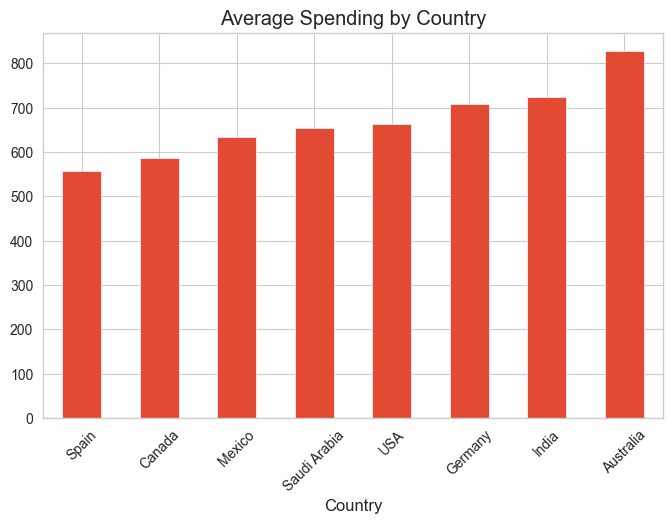

Country
Spain           557.374124
Canada          585.321887
Mexico          634.142857
Saudi Arabia    654.571123
USA             663.876010
Germany         707.236688
India           723.852306
Australia       827.378721
Name: Total_Spend, dtype: float64


In [20]:
country = df.groupby("Country")["Total_Spend"].mean().sort_values()

plt.figure(figsize=(8,5))

country.plot(kind="bar")

plt.xticks(rotation=45)

plt.title("Average Spending by Country")

plt.show()


print(country)

In [21]:
high = df[df["High_Spender"]=="Yes"]

print("High Spending Customers :", high.shape[0])

high[
[
"ID",
"Income",
"Total_Spend",
"Country",
"Education"
]
].head(10)

High Spending Customers : 5608


,ID,Income,Total_Spend,Country,Education
11,923176,104661.2,2109,Germany,Master
17,2275327,103586.0,1567,Spain,PhD
28,13912972,90351.9,1723,Canada,Graduation
30,9754902,65172.4,1859,Spain,Master
31,6167587,105043.4,1725,USA,Graduation
34,3620143,107197.9,1738,Australia,Master
39,16438440,99387.4,1576,Canada,PhD
53,15452824,93350.4,2517,India,PhD
68,82023,110837.1,1763,Australia,Graduation
73,15304690,79149.7,2025,India,Graduation


In [22]:
summary = df.groupby("Income_Band").agg(
{
"Income":"mean",
"Total_Spend":"mean",
"Response":"mean",
"NumWebVisitsMonth":"mean",
"Total_Purchases":"mean"
})

summary

,Income,Total_Spend,Response,NumWebVisitsMonth,Total_Purchases
Income_Band,,,,,
Low,12304.335833,194.188395,0.050696,6.166746,9.238683
Medium,45572.543338,500.477963,0.117651,5.391907,12.609680
High,74763.269934,790.928715,0.182209,4.853803,14.812349
Very High,102150.722930,1141.252259,0.253539,4.127089,16.772215


In [23]:
top10 = df.sort_values(
"Total_Spend",
ascending=False
)

top10[
[
"ID",
"Income",
"Total_Spend",
"Country",
"Education"
]
].head(10)

,ID,Income,Total_Spend,Country,Education
16653,5753845,106284.4,3431,Australia,Master
50061,6943845,110978.8,3355,Canada,PhD
33887,16522661,97871.5,3338,Canada,Graduation
22273,13759135,114183.7,3338,Australia,PhD
5070,13943936,114483.0,3314,Australia,Graduation
39179,10694541,100601.6,3270,Canada,2n Cycle
8394,14059885,85036.2,3234,Spain,Graduation
17592,2837885,116832.6,3203,Saudi Arabia,PhD
55371,2295475,111109.4,3201,Canada,PhD
27202,16471314,114724.5,3198,Saudi Arabia,Master


In [24]:
print("BUSINESS INSIGHTS")
print("-"*50)

print("1. Highest spending product:")
print(product_spending.idxmax())

print("\n2. Best performing channel:")
print(channels.idxmax())

print("\n3. Best campaign:")
print(campaigns.idxmax())

print("\n4. Average Campaign Response Rate:")
print(round(df["Response"].mean()*100,2),"%")

print("\n5. Number of High Spenders:")
print(df[df["High_Spender"]=="Yes"].shape[0])

BUSINESS INSIGHTS
--------------------------------------------------
1. Highest spending product:
MntMeatProducts

2. Best performing channel:
NumStorePurchases

3. Best campaign:
Response

4. Average Campaign Response Rate:
14.76 %

5. Number of High Spenders:
5608


feature engineering

In [25]:
def customer_segment(row):

    # High Value Customer
    if row["Income"] > 75000 and row["Total_Spend"] > df["Total_Spend"].quantile(0.90):
        return "High Value"

    # Potential Customer
    elif row["Income"] > 75000 and row["Response"] == 0:
        return "Potential"

    # Loyal Customer
    elif row["Customer_Tenure"] > 700 and row["Total_Purchases"] > 20:
        return "Loyal"

    # Active Customer
    elif row["Total_Purchases"] >= 10:
        return "Active"

    # At Risk Customer
    elif row["Recency"] > 60:
        return "At Risk"

    # New Customer
    elif row["Customer_Tenure"] < 200:
        return "New"

    else:
        return "Regular"

df["Customer_Segment"] = df.apply(customer_segment, axis=1)

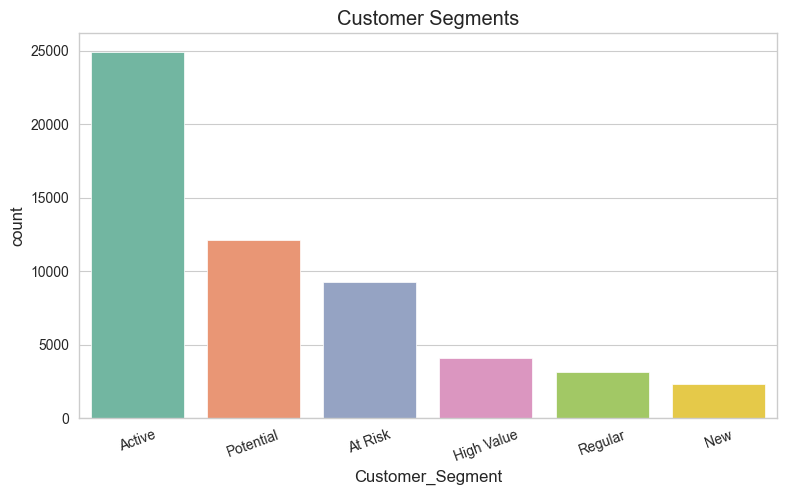

In [26]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Customer_Segment",
    order=df["Customer_Segment"].value_counts().index,
    palette="Set2"
)

plt.xticks(rotation=20)

plt.title("Customer Segments")

plt.show()

In [27]:
segment_summary = df.groupby("Customer_Segment").agg({

"Income":"mean",

"Total_Spend":"mean",

"Total_Purchases":"mean",

"Response":"mean",

"NumWebVisitsMonth":"mean"

}).round(2)

segment_summary

,Income,Total_Spend,Total_Purchases,Response,NumWebVisitsMonth
Customer_Segment,,,,,
Active,51132.00,600.26,15.20,0.24,5.19
At Risk,25152.80,209.09,6.67,0.06,6.08
High Value,99059.55,1997.02,17.40,0.28,3.83
New,26104.98,226.77,6.76,0.07,6.06
Potential,93442.21,765.21,15.71,0.00,4.53
Regular,29123.07,273.06,6.86,0.09,5.94


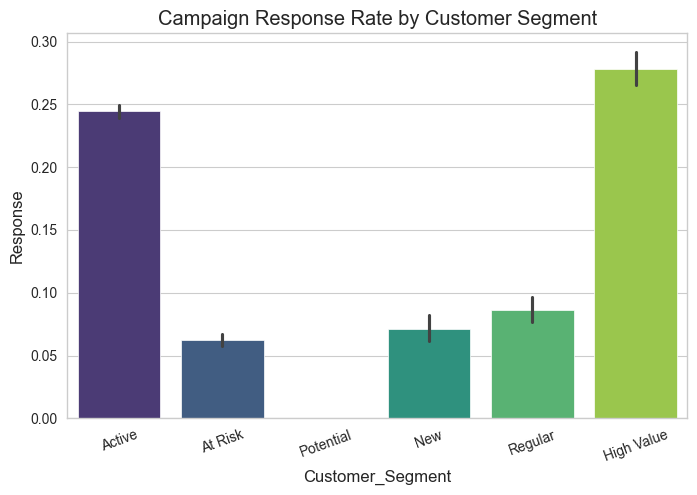

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(

data=df,

x="Customer_Segment",

y="Response",

estimator=np.mean,

palette="viridis"

)

plt.xticks(rotation=20)

plt.title("Campaign Response Rate by Customer Segment")

plt.show()

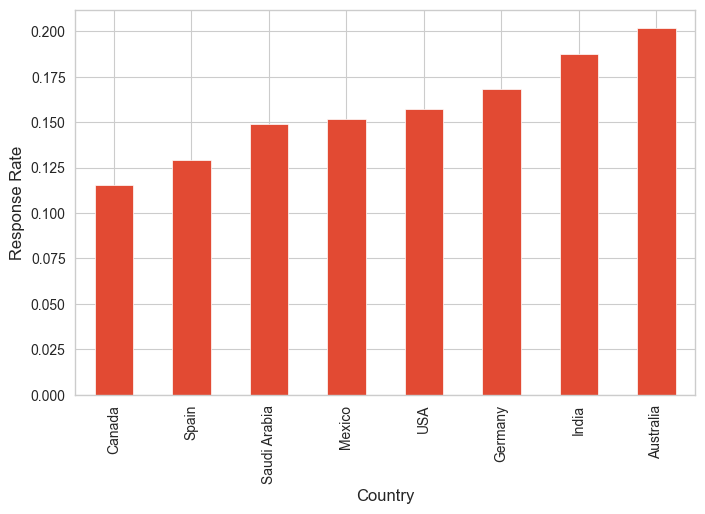

Country
Canada          0.115671
Spain           0.129318
Saudi Arabia    0.149014
Mexico          0.152000
USA             0.157008
Germany         0.168096
India           0.187578
Australia       0.201867
Name: Response, dtype: float64

In [29]:
country_response = df.groupby("Country")["Response"].mean().sort_values()

plt.figure(figsize=(8,5))

country_response.plot(kind="bar")

plt.ylabel("Response Rate")

plt.show()

country_response

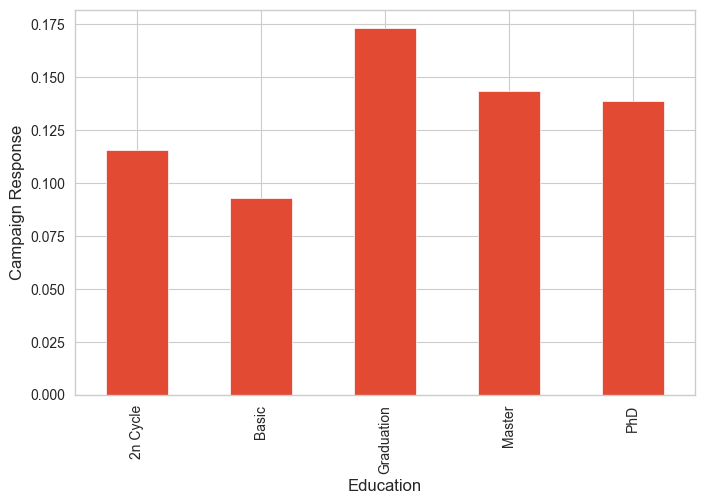

In [30]:
education = df.groupby("Education")["Response"].mean()

plt.figure(figsize=(8,5))

education.plot(kind="bar")

plt.ylabel("Campaign Response")

plt.show()

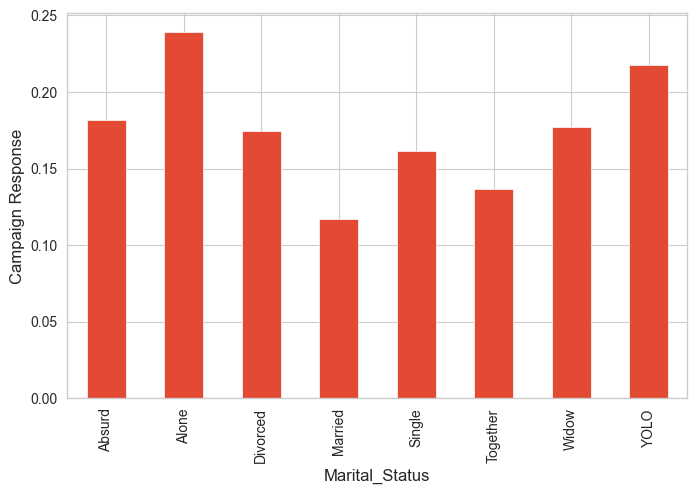

In [31]:
marital = df.groupby("Marital_Status")["Response"].mean()

plt.figure(figsize=(8,5))

marital.plot(kind="bar")

plt.ylabel("Campaign Response")

plt.show()

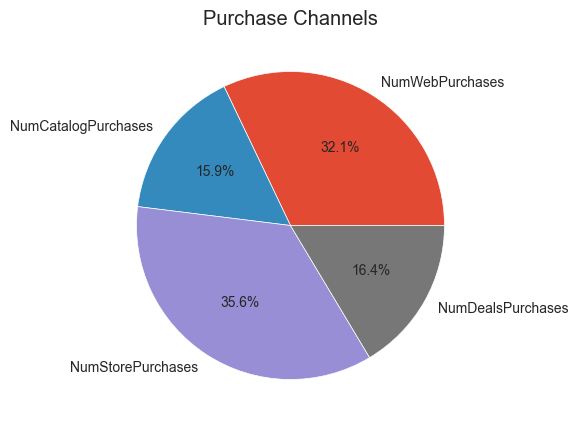

In [32]:
channels = df[
[
"NumWebPurchases",
"NumCatalogPurchases",
"NumStorePurchases",
"NumDealsPurchases"
]
].sum()

plt.figure(figsize=(8,5))

plt.pie(
channels,
labels=channels.index,
autopct="%1.1f%%"
)

plt.title("Purchase Channels")

plt.show()

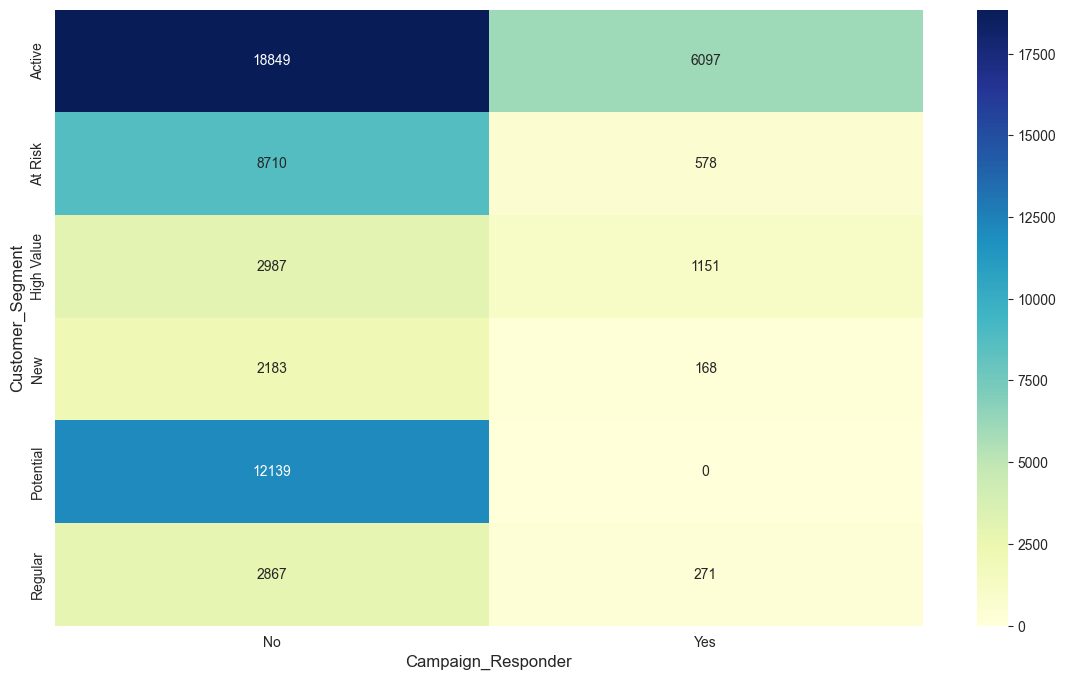

In [33]:
plt.figure(figsize=(14,8))

sns.heatmap(

pd.crosstab(

df["Customer_Segment"],

df["Campaign_Responder"]

),

annot=True,

fmt='d',

cmap="YlGnBu"

)

plt.show()

In [34]:
print("="*60)
print("BUSINESS RECOMMENDATIONS")
print("="*60)

print("""
1. Target High Value customers with premium campaigns.

2. Potential customers have high income but low response.
   Personalized offers can improve conversions.

3. Loyal customers should receive exclusive loyalty rewards.

4. Increase digital marketing for highly engaged website visitors.

5. Focus campaigns on countries with higher response rates.

6. Promote products with lower sales using bundle offers.

7. Reduce marketing spend on At Risk customers unless retention campaigns are planned.
""")

BUSINESS RECOMMENDATIONS

1. Target High Value customers with premium campaigns.

2. Potential customers have high income but low response.
   Personalized offers can improve conversions.

3. Loyal customers should receive exclusive loyalty rewards.

4. Increase digital marketing for highly engaged website visitors.

5. Focus campaigns on countries with higher response rates.

6. Promote products with lower sales using bundle offers.

7. Reduce marketing spend on At Risk customers unless retention campaigns are planned.



In [35]:
# ==========================
# BUSINESS KPI SUMMARY
# ==========================

print("="*60)
print("MARKETING CAMPAIGN KPI SUMMARY")
print("="*60)

kpis = {
    "Total Customers": len(df),
    "Average Age": round(df["Age"].mean(),2),
    "Average Income": round(df["Income"].mean(),2),
    "Average Spend": round(df["Total_Spend"].mean(),2),
    "Average Purchases": round(df["Total_Purchases"].mean(),2),
    "Campaign Response Rate (%)": round(df["Response"].mean()*100,2),
    "Average Website Visits": round(df["NumWebVisitsMonth"].mean(),2),
    "Complaint Rate (%)": round(df["Complain"].mean()*100,2)
}

kpi_df = pd.DataFrame(kpis.items(), columns=["KPI","Value"])
display(kpi_df)

print("\nTop 10 Customers")
display(
    df.sort_values("Total_Spend", ascending=False)[
        ["ID","Income","Total_Spend","Country","Education"]
    ].head(10)
)

MARKETING CAMPAIGN KPI SUMMARY


,KPI,Value
0,Total Customers,56000.00
1,Average Age,53.33
2,Average Income,57252.19
3,Average Spend,640.33
4,Average Purchases,13.24
5,Campaign Response Rate (%),14.76
6,Average Website Visits,5.17
7,Complaint Rate (%),0.76



Top 10 Customers


,ID,Income,Total_Spend,Country,Education
16653,5753845,106284.4,3431,Australia,Master
50061,6943845,110978.8,3355,Canada,PhD
33887,16522661,97871.5,3338,Canada,Graduation
22273,13759135,114183.7,3338,Australia,PhD
5070,13943936,114483.0,3314,Australia,Graduation
39179,10694541,100601.6,3270,Canada,2n Cycle
8394,14059885,85036.2,3234,Spain,Graduation
17592,2837885,116832.6,3203,Saudi Arabia,PhD
55371,2295475,111109.4,3201,Canada,PhD
27202,16471314,114724.5,3198,Saudi Arabia,Master


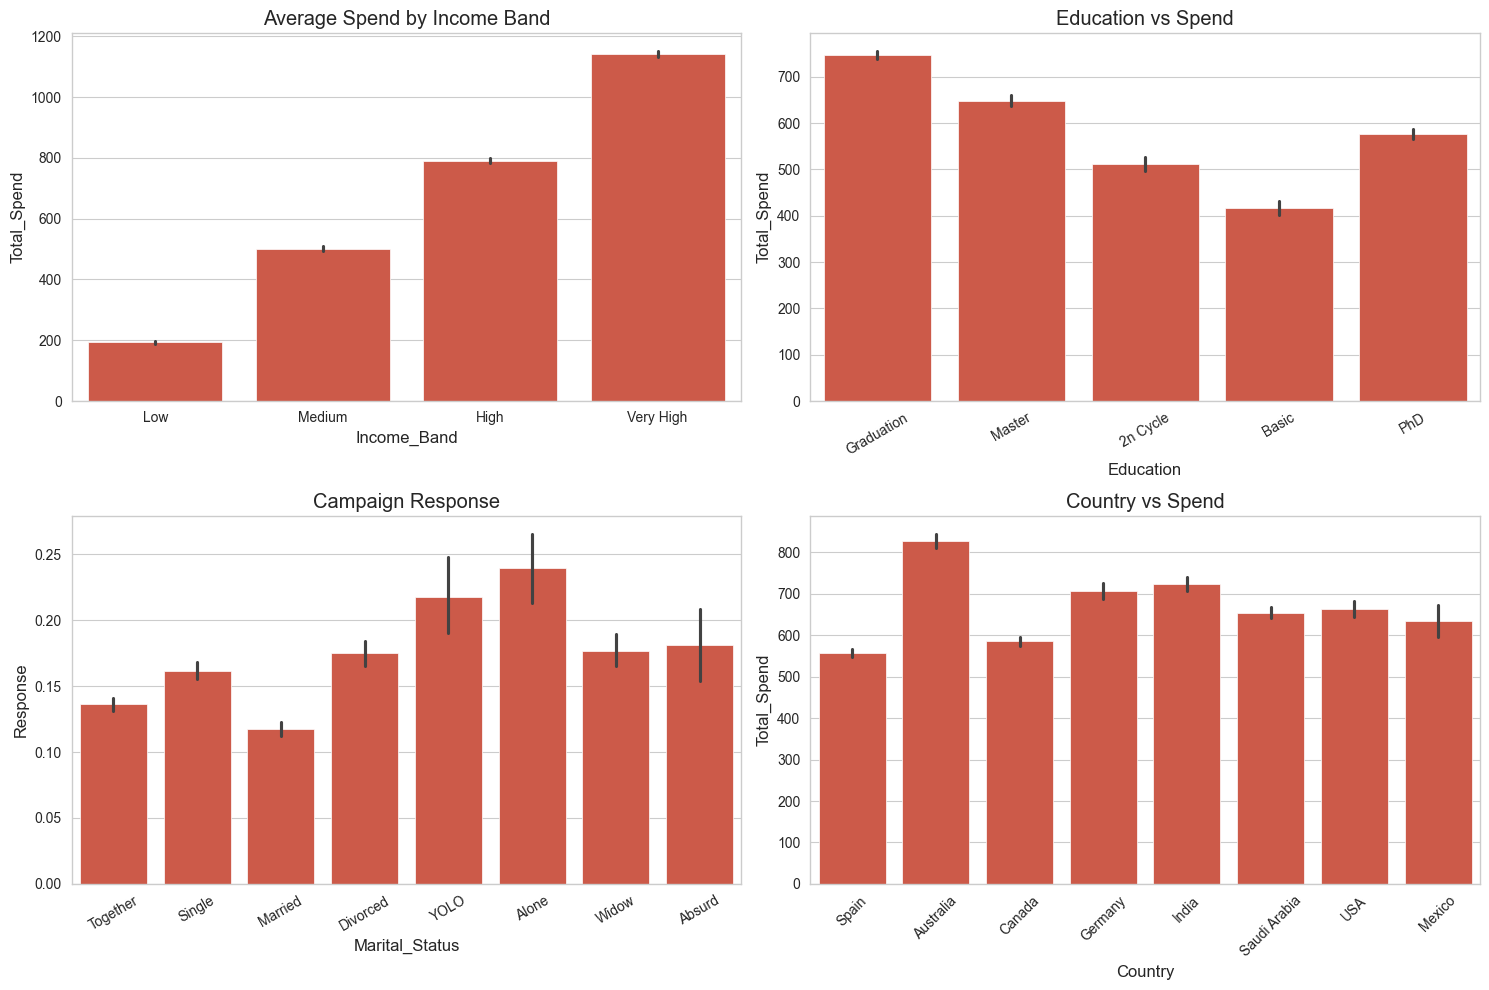

In [36]:
# ==========================
# BUSINESS ANALYSIS
# ==========================

fig, ax = plt.subplots(2,2, figsize=(15,10))

# Income Band
sns.barplot(
    data=df,
    x="Income_Band",
    y="Total_Spend",
    estimator=np.mean,
    ax=ax[0,0]
)
ax[0,0].set_title("Average Spend by Income Band")

# Education
sns.barplot(
    data=df,
    x="Education",
    y="Total_Spend",
    estimator=np.mean,
    ax=ax[0,1]
)
ax[0,1].tick_params(axis='x',rotation=30)
ax[0,1].set_title("Education vs Spend")

# Marital
sns.barplot(
    data=df,
    x="Marital_Status",
    y="Response",
    estimator=np.mean,
    ax=ax[1,0]
)
ax[1,0].tick_params(axis='x',rotation=30)
ax[1,0].set_title("Campaign Response")

# Country
sns.barplot(
    data=df,
    x="Country",
    y="Total_Spend",
    estimator=np.mean,
    ax=ax[1,1]
)
ax[1,1].tick_params(axis='x',rotation=45)
ax[1,1].set_title("Country vs Spend")

plt.tight_layout()
plt.show()

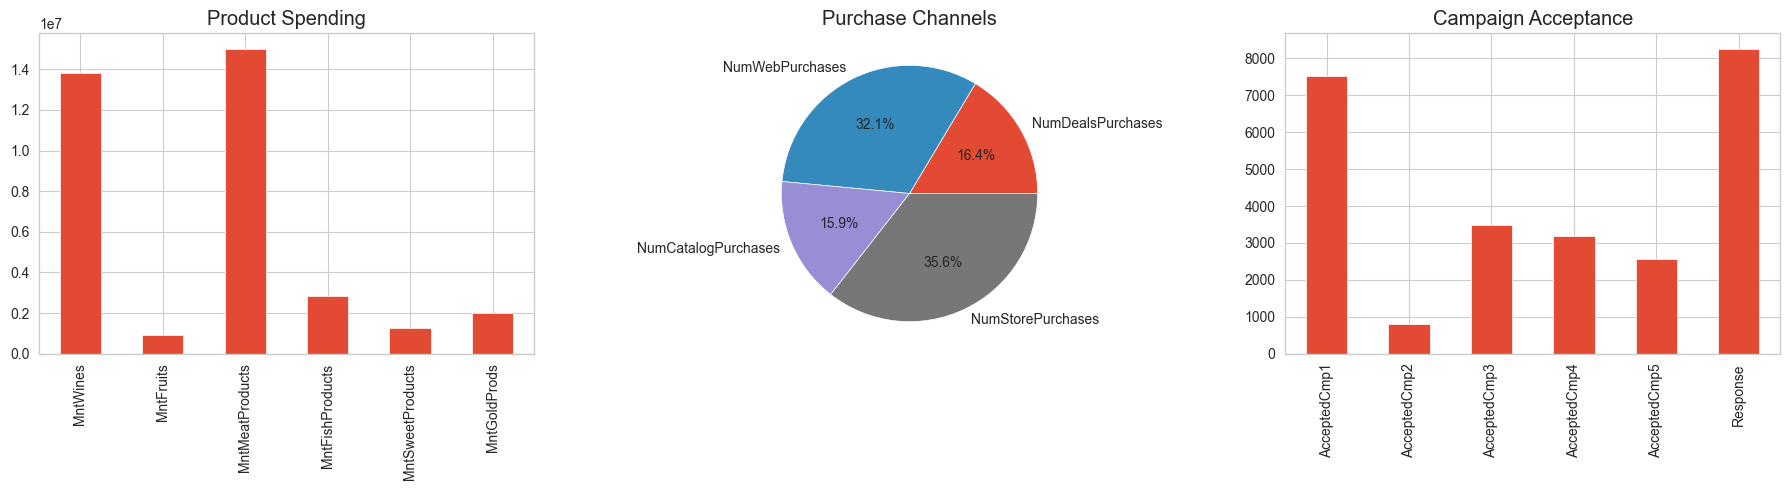

In [37]:
# ==========================
# PRODUCT, CHANNEL & CAMPAIGN
# ==========================

fig, ax = plt.subplots(1,3, figsize=(18,5))

# Product
product_sales = df[
[
"MntWines",
"MntFruits",
"MntMeatProducts",
"MntFishProducts",
"MntSweetProducts",
"MntGoldProds"
]
].sum()

product_sales.plot(kind="bar", ax=ax[0])
ax[0].set_title("Product Spending")

# Purchase Channels
channel_sales = df[
[
"NumDealsPurchases",
"NumWebPurchases",
"NumCatalogPurchases",
"NumStorePurchases"
]
].sum()

channel_sales.plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
ax[1].set_ylabel("")
ax[1].set_title("Purchase Channels")

# Campaigns
campaigns = df[
[
"AcceptedCmp1",
"AcceptedCmp2",
"AcceptedCmp3",
"AcceptedCmp4",
"AcceptedCmp5",
"Response"
]
].sum()

campaigns.plot(kind="bar", ax=ax[2])
ax[2].set_title("Campaign Acceptance")

plt.tight_layout()
plt.show()

,Income,Total_Spend,Total_Purchases,Response,NumWebVisitsMonth
Customer_Segment,,,,,
Active,51132.00,600.26,15.20,0.24,5.19
At Risk,25152.80,209.09,6.67,0.06,6.08
High Value,99059.55,1997.02,17.40,0.28,3.83
New,26104.98,226.77,6.76,0.07,6.06
Potential,93442.21,765.21,15.71,0.00,4.53
Regular,29123.07,273.06,6.86,0.09,5.94


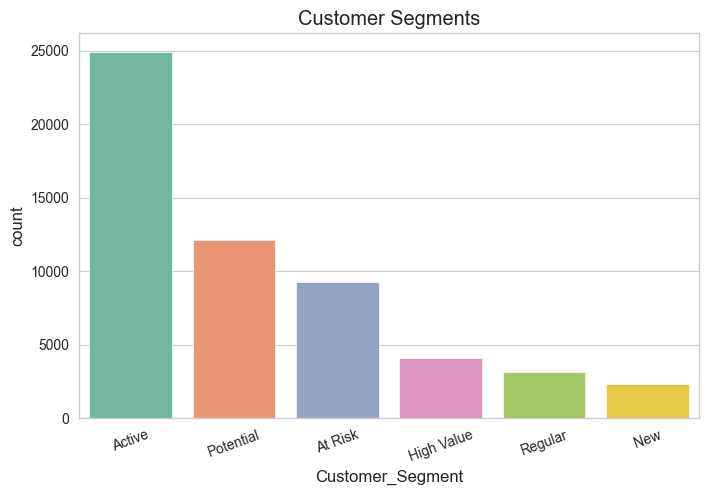

BUSINESS RECOMMENDATIONS
1. Target High Value customers with premium campaigns.
2. Retarget Potential customers using personalized offers.
3. Reward Loyal customers with exclusive benefits.
4. Focus on countries with higher campaign response rates.
5. Increase digital marketing for highly engaged web users.
6. Bundle low-selling products with best-selling products.


In [38]:
# ==========================
# CUSTOMER SEGMENTATION
# ==========================

segment_summary = df.groupby("Customer_Segment").agg({

"Income":"mean",
"Total_Spend":"mean",
"Total_Purchases":"mean",
"Response":"mean",
"NumWebVisitsMonth":"mean"

}).round(2)

display(segment_summary)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Customer_Segment",
    order=df["Customer_Segment"].value_counts().index,
    palette="Set2"
)

plt.xticks(rotation=20)
plt.title("Customer Segments")
plt.show()

print("="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

recommendations = [
    "Target High Value customers with premium campaigns.",
    "Retarget Potential customers using personalized offers.",
    "Reward Loyal customers with exclusive benefits.",
    "Focus on countries with higher campaign response rates.",
    "Increase digital marketing for highly engaged web users.",
    "Bundle low-selling products with best-selling products.",
]

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

In [39]:
import sqlite3

# Create database
conn = sqlite3.connect("marketing_campaign.db")

# Export dataframe to SQL table
df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Database Created Successfully")
print("Table Created Successfully")

# Verify
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
""", conn)

display(tables)

Database Created Successfully
Table Created Successfully


,name
0,customers


In [40]:
queries = {

"Total Customers":
"""
SELECT COUNT(*) AS Total_Customers
FROM customers
""",

"Average Income":
"""
SELECT ROUND(AVG(Income),2) AS Avg_Income
FROM customers
""",

"Average Spend":
"""
SELECT ROUND(AVG(Total_Spend),2) AS Avg_Spend
FROM customers
""",

"Response Rate":
"""
SELECT ROUND(AVG(Response)*100,2) AS Response_Rate
FROM customers
""",

"Average Web Visits":
"""
SELECT ROUND(AVG(NumWebVisitsMonth),2) AS Avg_Web_Visits
FROM customers
"""

}

for title, sql in queries.items():

    print("="*60)
    print(title)

    display(pd.read_sql(sql, conn))

Total Customers


,Total_Customers
0,56000


Average Income


,Avg_Income
0,57252.19


Average Spend


,Avg_Spend
0,640.33


Response Rate


,Response_Rate
0,14.76


Average Web Visits


,Avg_Web_Visits
0,5.17


In [41]:
segment_queries = {

"Income Band":

"""
SELECT
Income_Band,
COUNT(*) Customers,
ROUND(AVG(Total_Spend),2) Avg_Spend,
ROUND(AVG(Response)*100,2) Response_Rate
FROM customers
GROUP BY Income_Band
""",

"Education":

"""
SELECT
Education,
COUNT(*) Customers,
ROUND(AVG(Total_Spend),2) Avg_Spend,
ROUND(AVG(Response)*100,2) Response_Rate
FROM customers
GROUP BY Education
""",

"Marital Status":

"""
SELECT
Marital_Status,
COUNT(*) Customers,
ROUND(AVG(Total_Spend),2) Avg_Spend,
ROUND(AVG(Response)*100,2) Response_Rate
FROM customers
GROUP BY Marital_Status
""",

"Country":

"""
SELECT
Country,
COUNT(*) Customers,
ROUND(AVG(Total_Spend),2) Avg_Spend,
ROUND(AVG(Response)*100,2) Response_Rate
FROM customers
GROUP BY Country
""",

"Customer Segment":

"""
SELECT
Customer_Segment,
COUNT(*) Customers,
ROUND(AVG(Total_Spend),2) Avg_Spend,
ROUND(AVG(Total_Purchases),2) Avg_Purchases
FROM customers
GROUP BY Customer_Segment
"""

}

for title, sql in segment_queries.items():

    print("="*60)
    print(title)

    display(pd.read_sql(sql, conn))

Income Band


,Income_Band,Customers,Avg_Spend,Response_Rate
0,None,15,1198.93,33.33
1,High,14884,790.93,18.22
2,Low,14735,194.19,5.07
3,Medium,13863,500.48,11.77
4,Very High,12503,1141.25,25.35


Education


,Education,Customers,Avg_Spend,Response_Rate
0,2n Cycle,5966,511.30,11.55
1,Basic,4182,416.46,9.28
2,Graduation,22741,747.35,17.30
3,Master,10530,648.50,14.35
4,PhD,12581,575.67,13.85


Marital Status


,Marital_Status,Customers,Avg_Spend,Response_Rate
0,Absurd,733,655.35,18.14
1,Alone,911,701.29,23.93
2,Divorced,6459,753.91,17.48
3,Married,13686,504.91,11.72
4,Single,12238,688.19,16.17
5,Together,17703,644.77,13.65
6,Widow,3540,745.05,17.68
7,YOLO,730,665.59,21.78


Country


,Country,Customers,Avg_Spend,Response_Rate
0,Australia,5677,827.38,20.19
1,Canada,10746,585.32,11.57
2,Germany,4432,707.24,16.81
3,India,4814,723.85,18.76
4,Mexico,875,634.14,15.20
5,Saudi Arabia,8422,654.57,14.90
6,Spain,16703,557.37,12.93
7,USA,4331,663.88,15.70


Customer Segment


,Customer_Segment,Customers,Avg_Spend,Avg_Purchases
0,Active,24946,600.26,15.20
1,At Risk,9288,209.09,6.67
2,High Value,4138,1997.02,17.40
3,New,2351,226.77,6.76
4,Potential,12139,765.21,15.71
5,Regular,3138,273.06,6.86


In [42]:
print("="*60)
print("PRODUCT SALES")
display(pd.read_sql("""

SELECT

SUM(MntWines) Wines,
SUM(MntFruits) Fruits,
SUM(MntMeatProducts) Meat,
SUM(MntFishProducts) Fish,
SUM(MntSweetProducts) Sweets,
SUM(MntGoldProds) Gold

FROM customers

""", conn))

print("="*60)
print("PURCHASE CHANNELS")

display(pd.read_sql("""

SELECT

SUM(NumWebPurchases) Web,
SUM(NumCatalogPurchases) Catalog,
SUM(NumStorePurchases) Store,
SUM(NumDealsPurchases) Deals

FROM customers

""", conn))

print("="*60)
print("CAMPAIGN PERFORMANCE")

display(pd.read_sql("""

SELECT

SUM(AcceptedCmp1) Campaign1,
SUM(AcceptedCmp2) Campaign2,
SUM(AcceptedCmp3) Campaign3,
SUM(AcceptedCmp4) Campaign4,
SUM(AcceptedCmp5) Campaign5,
SUM(Response) LatestCampaign

FROM customers

""", conn))

PRODUCT SALES


,Wines,Fruits,Meat,Fish,Sweets,Gold
0,13830963,904549,15024465,2861473,1255691,1981595


PURCHASE CHANNELS


,Web,Catalog,Store,Deals
0,237938,118202,263559,121630


CAMPAIGN PERFORMANCE


,Campaign1,Campaign2,Campaign3,Campaign4,Campaign5,LatestCampaign
0,7529,807,3494,3182,2557,8265


In [43]:
customer_summary = pd.read_sql("""

SELECT

Customer_Segment,

COUNT(*) AS Customers,

ROUND(AVG(Total_Spend),2) AS Avg_Spend,

ROUND(AVG(Response)*100,2) AS Response_Rate,

ROUND(AVG(NumWebVisitsMonth),2) AS Avg_Web_Visits

FROM customers

GROUP BY Customer_Segment

""", conn)

customer_summary

,Customer_Segment,Customers,Avg_Spend,Response_Rate,Avg_Web_Visits
0,Active,24946,600.26,24.44,5.19
1,At Risk,9288,209.09,6.22,6.08
2,High Value,4138,1997.02,27.82,3.83
3,New,2351,226.77,7.15,6.06
4,Potential,12139,765.21,0.00,4.53
5,Regular,3138,273.06,8.64,5.94


In [44]:

!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [45]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Age,Customer_Tenure,Children,Total_Spend,Total_Purchases,Campaign_Count,Income_Band,Age_Group,High_Spender,High_Web_Engagement,Campaign_Responder,Customer_Segment
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,2,45,6,0,16,3,2,5,3,4,0,0,0,0,0,0,0,Spain,40,589,1,69,13,0,Medium,31-40,No,No,No,Active
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,0,19,1,19,0,1,1,0,2,3,0,0,0,0,0,0,0,Spain,50,445,2,39,4,0,Low,41-50,No,No,No,At Risk
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,0,339,0,115,138,3,2,1,6,3,0,0,0,0,0,0,0,Australia,47,169,0,1512,12,0,Very High,41-50,No,No,No,Potential
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,0,130,7,1,75,1,4,0,11,4,0,0,0,0,0,0,0,Spain,49,11,1,478,16,0,High,41-50,No,No,No,Active
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,3,55,242,0,0,1,3,2,3,6,0,0,0,0,0,0,0,Canada,44,40,2,330,9,0,Medium,41-50,No,Yes,No,New


In [46]:
df.to_csv("marketing_campaign_final.csv", index=False)

print("File Saved Successfully")

File Saved Successfully


In [48]:
st.sidebar.header("Filters")

country = st.sidebar.multiselect(
    "Country",
    options=df["Country"].unique(),
    default=df["Country"].unique()
)

education = st.sidebar.multiselect(
    "Education",
    options=df["Education"].unique(),
    default=df["Education"].unique()
)

segment = st.sidebar.multiselect(
    "Customer Segment",
    options=df["Customer_Segment"].unique(),
    default=df["Customer_Segment"].unique()
)

filtered = df[
    (df["Country"].isin(country)) &
    (df["Education"].isin(education)) &
    (df["Customer_Segment"].isin(segment))
]

col1,col2,col3,col4 = st.columns(4)

col1.metric("Customers",len(filtered))
col2.metric("Avg Income",f"₹{filtered['Income'].mean():,.0f}")
col3.metric("Avg Spend",f"₹{filtered['Total_Spend'].mean():,.0f}")
col4.metric("Response Rate",f"{filtered['Response'].mean()*100:.2f}%")

2026-06-30 13:48:33.041 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:33.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:33.046 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:33.052 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:33.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:33.056 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:33.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:33.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

2026-06-30 13:48:43.172 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:43.172 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:43.173 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:43.173 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:43.174 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:43.174 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:43.244 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:43.318 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

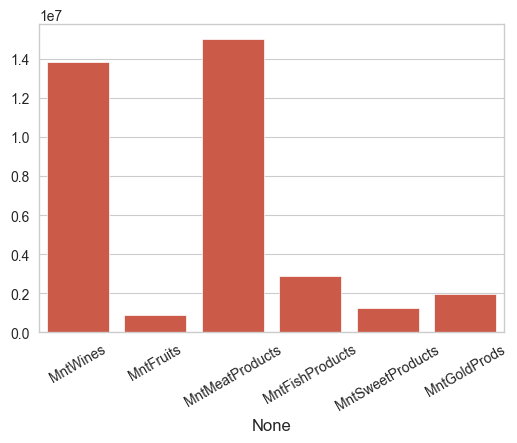

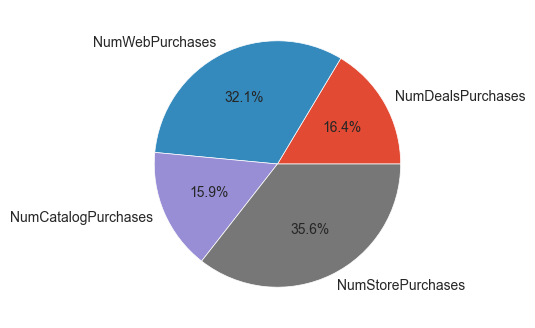

In [49]:
col1,col2 = st.columns(2)

with col1:

    st.subheader("Product Spending")

    product = filtered[
        [
            "MntWines",
            "MntFruits",
            "MntMeatProducts",
            "MntFishProducts",
            "MntSweetProducts",
            "MntGoldProds"
        ]
    ].sum()

    fig,ax=plt.subplots(figsize=(6,4))

    sns.barplot(
        x=product.index,
        y=product.values,
        ax=ax
    )

    plt.xticks(rotation=30)

    st.pyplot(fig)

with col2:

    st.subheader("Purchase Channels")

    channels = filtered[
        [
            "NumDealsPurchases",
            "NumWebPurchases",
            "NumCatalogPurchases",
            "NumStorePurchases"
        ]
    ].sum()

    fig,ax=plt.subplots(figsize=(6,4))

    ax.pie(
        channels,
        labels=channels.index,
        autopct="%1.1f%%"
    )

    st.pyplot(fig)

In [50]:
col1,col2 = st.columns(2)

with col1:

    st.subheader("Customer Segments")

    fig,ax=plt.subplots(figsize=(6,4))

    sns.countplot(
        data=filtered,
        x="Customer_Segment",
        order=filtered["Customer_Segment"].value_counts().index,
        ax=ax
    )

    plt.xticks(rotation=20)

    st.pyplot(fig)

with col2:

    st.subheader("Campaign Response")

    fig,ax=plt.subplots(figsize=(6,4))

    sns.countplot(
        data=filtered,
        x="Campaign_Responder",
        ax=ax
    )

    st.pyplot(fig)

2026-06-30 13:48:56.070 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:56.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:56.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:56.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:56.073 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:56.074 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:56.128 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:48:56.170 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [51]:
st.subheader("Correlation Heatmap")

fig,ax=plt.subplots(figsize=(10,7))

sns.heatmap(
    filtered.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    ax=ax
)

st.pyplot(fig)

st.subheader("Customer Data")

st.dataframe(filtered)

2026-06-30 13:49:03.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:03.500 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:03.500 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:03.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:03.909 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:03.909 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:03.909 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:03.910 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [52]:
st.subheader("Business Insights")

st.success(f"""
✔ Total Customers : {len(filtered)}

✔ Average Income : ₹{filtered['Income'].mean():,.0f}

✔ Average Spend : ₹{filtered['Total_Spend'].mean():,.0f}

✔ Campaign Response Rate : {filtered['Response'].mean()*100:.2f}%

✔ Best Selling Product :
{filtered[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum().idxmax()}

✔ Best Purchase Channel :
{filtered[['NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum().idxmax()}
""")

2026-06-30 13:49:11.872 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:11.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:11.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:11.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:11.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-30 13:49:11.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()